In [ ]:

# 导入常用库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt   # 画图用
import seaborn as sns             # 更美观的统计图
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

# 读取训练集和测试集
df = pd.read_csv(r'C:\Users\XUE\source\repos\Kaggle\Titanic\Titanic\train.csv')

test = pd.read_csv(r'C:\Users\XUE\source\repos\Kaggle\Titanic\Titanic\test.csv')

# 先大致看看数据长什么样
print("DATA SHAPE:")
print(f"Rows: {df.shape[0]}, Columns: {df.shape[1]}")
print()

print("DATA TYPES:")
print(df.dtypes)
print()

print("FIRST 5 ROWS:")
print(df.head())
print()

print("LAST 5 ROWS:")
print(df.tail())
print()

print("BASIC STATISTICS:")
print(df.describe())
print()

# 统计缺失值数量和比例
print("MISSING VALUES:")
missing_data = df.isnull().sum()
missing_percent = (missing_data / len(df)) * 100
missing_table = pd.DataFrame({
    'Missing Values': missing_data,
    'Percentage': missing_percent
})
print(missing_table[missing_table['Missing Values'] > 0])
print()

DATA SHAPE:
Rows: 891, Columns: 12

DATA TYPES:
PassengerId      int64
Survived         int64
Pclass           int64
Name               str
Sex                str
Age            float64
SibSp            int64
Parch            int64
Ticket             str
Fare           float64
Cabin              str
Embarked           str
dtype: object

FIRST 5 ROWS:
   PassengerId  Survived  Pclass  \
0            1         0       3   
1            2         1       1   
2            3         1       3   
3            4         1       1   
4            5         0       3   

                                                Name     Sex   Age  SibSp  \
0                            Braund, Mr. Owen Harris    male  22.0      1   
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female  38.0      1   
2                             Heikkinen, Miss. Laina  female  26.0      0   
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1   
4                           Allen, Mr. Willia

In [181]:
# 查看一下类别特征（文本型）里都有哪些不同的取值
print("UNIQUE VALUES IN CATEGORICAL FEATURES:")

# 选出所有数据类型为 object 的列（一般是字符串）
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    # 打印该列有多少个不同的值
    print(f"{col}: {df[col].nunique()} unique values")
    
    # 如果不同值少于10个，顺便把具体值也打印出来，方便了解情况
    if df[col].nunique() < 10:
        print(f"  Values: {df[col].unique()}")
print()

UNIQUE VALUES IN CATEGORICAL FEATURES:
Name: 891 unique values
Sex: 2 unique values
  Values: <StringArray>
['male', 'female']
Length: 2, dtype: str
Ticket: 681 unique values
Cabin: 147 unique values
Embarked: 3 unique values
  Values: <StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str



C:\Users\xiaoh\AppData\Local\Temp\ipykernel_44176\3022342195.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


CORRELATION MATRIX:


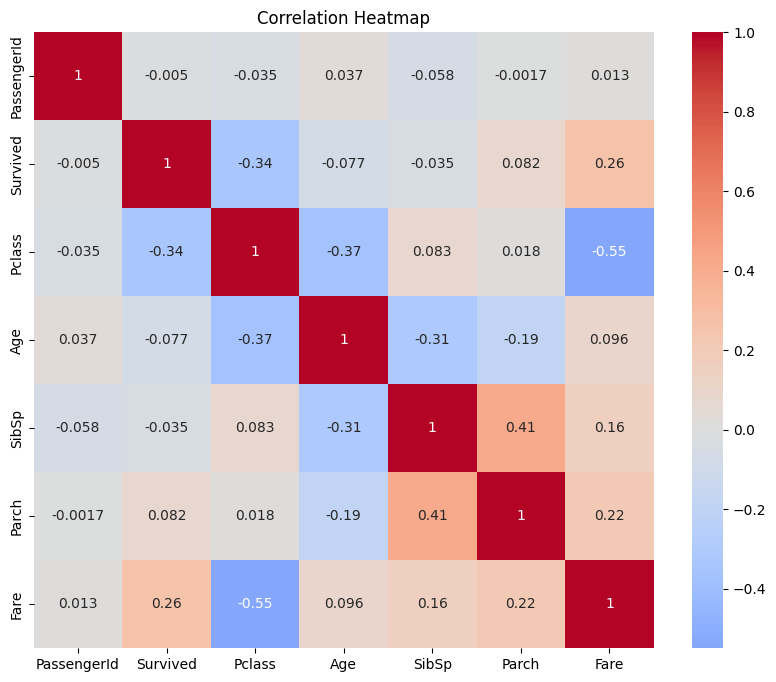

In [182]:
# 看一下数值型特征之间的相关性强弱
print("CORRELATION MATRIX:")

# 只挑出数值类型的列（整数或小数），因为相关性只能算数值型
numeric_df = df.select_dtypes(include=[np.number])

# 计算这些列两两之间的相关系数（-1到1，绝对值越大相关性越强）
correlation_matrix = numeric_df.corr()

# 画一张热力图，直观展示相关性
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()
print()

In [183]:
# 查看类别特征（文本类型）中有多少种不同的取值
print("UNIQUE VALUES IN CATEGORICAL FEATURES:")

# 选出所有数据类型为 object 的列（通常是字符串）
categorical_cols = df.select_dtypes(include=['object']).columns

for col in categorical_cols:
    # 输出该列不同值的数量
    print(f"{col}: {df[col].nunique()} unique values")
    
    # 如果不同值少于10个，就把具体值也列出来，方便了解分布
    if df[col].nunique() < 10:
        print(f"  Values: {df[col].unique()}")
print()

UNIQUE VALUES IN CATEGORICAL FEATURES:
Name: 891 unique values
Sex: 2 unique values
  Values: <StringArray>
['male', 'female']
Length: 2, dtype: str
Ticket: 681 unique values
Cabin: 147 unique values
Embarked: 3 unique values
  Values: <StringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str



C:\Users\xiaoh\AppData\Local\Temp\ipykernel_44176\2175072240.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object']).columns


CORRELATION MATRIX:


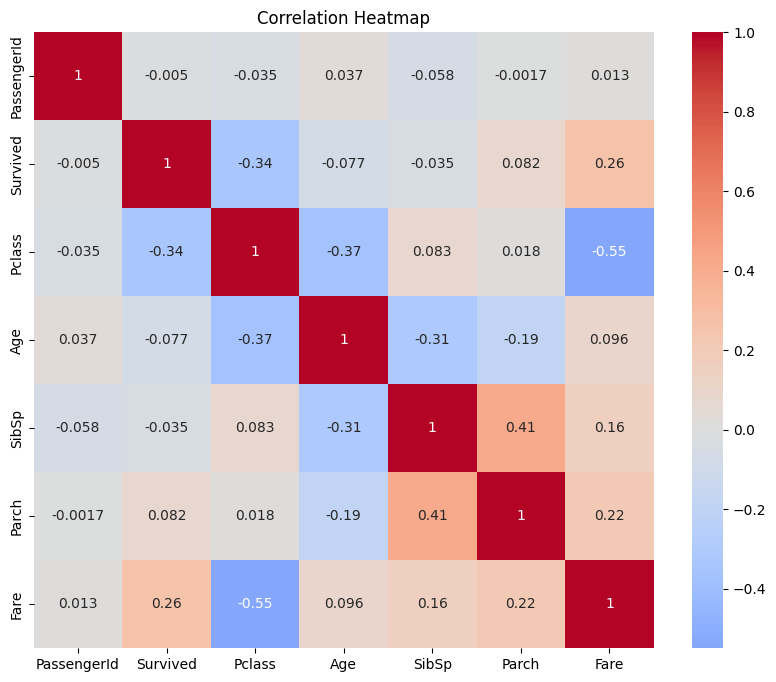

In [184]:
# 计算并可视化数值型特征之间的相关系数矩阵
print("CORRELATION MATRIX:")

# 只选取数值类型的列（整数或浮点数）
numeric_df = df.select_dtypes(include=[np.number])

# 计算相关系数矩阵，取值在 -1 到 1 之间
correlation_matrix = numeric_df.corr()

# 设置画布大小，绘制热力图
plt.figure(figsize=(10, 8))
# annot=True 表示在格子里显示数值，cmap 是颜色映射，center=0 让 0 对应的颜色居中
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()
print()

TARGET DISTRIBUTION:


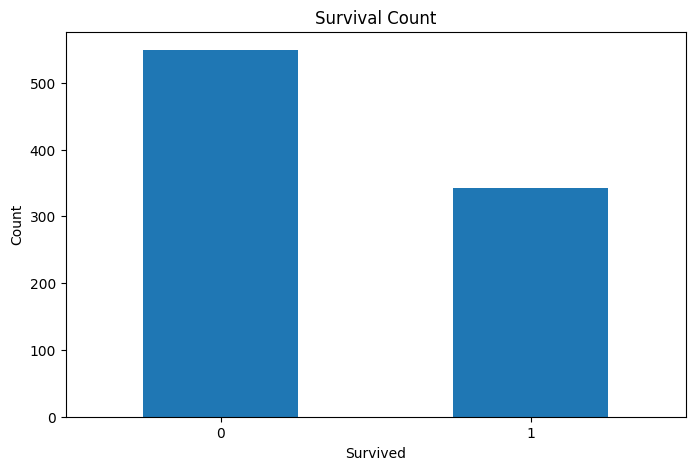

Survived
0    0.616162
1    0.383838
Name: proportion, dtype: float64



In [185]:
# 查看目标变量（是否幸存）的分布情况
print("TARGET DISTRIBUTION:")

# 检查训练集中是否存在 Survived 列（测试集没有，这里主要是训练集用）
if 'Survived' in df.columns: 
    # 设置画布大小
    plt.figure(figsize=(8, 5))
    # 画条形图：统计幸存和遇难的人数
    df['Survived'].value_counts().plot(kind='bar')
    plt.title('Survival Count')
    plt.xlabel('Survived')
    plt.ylabel('Count')
    plt.xticks(rotation=0)  # x轴标签不旋转，0和1水平显示
    plt.show()
    
    # 打印幸存比例的详细信息（0和1分别占多少）
    print(df['Survived'].value_counts(normalize=True))
print()

NUMERICAL FEATURES DISTRIBUTION:


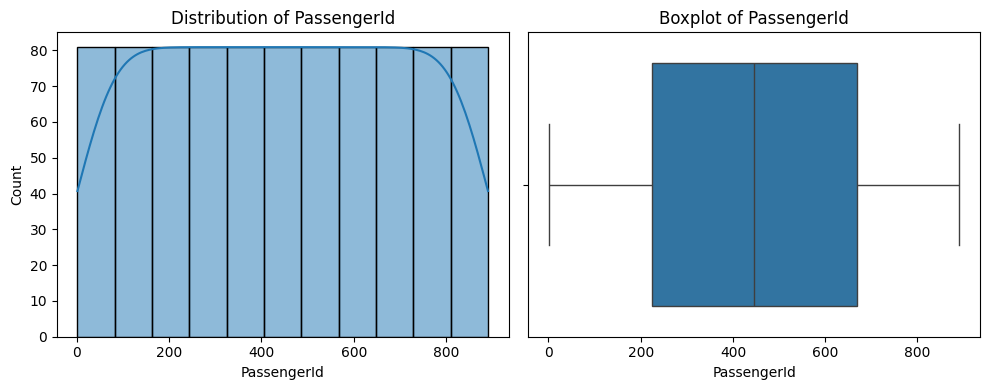

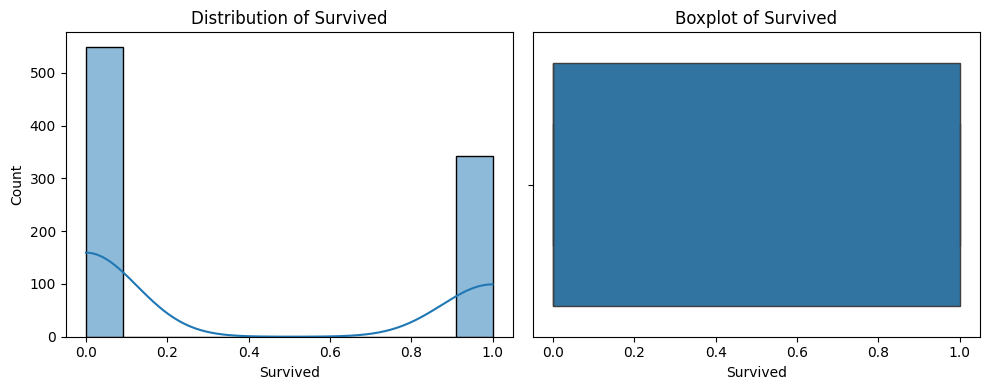

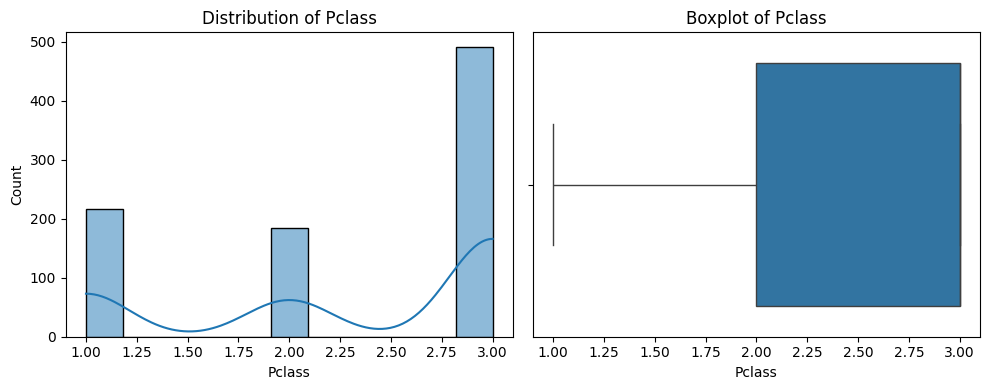

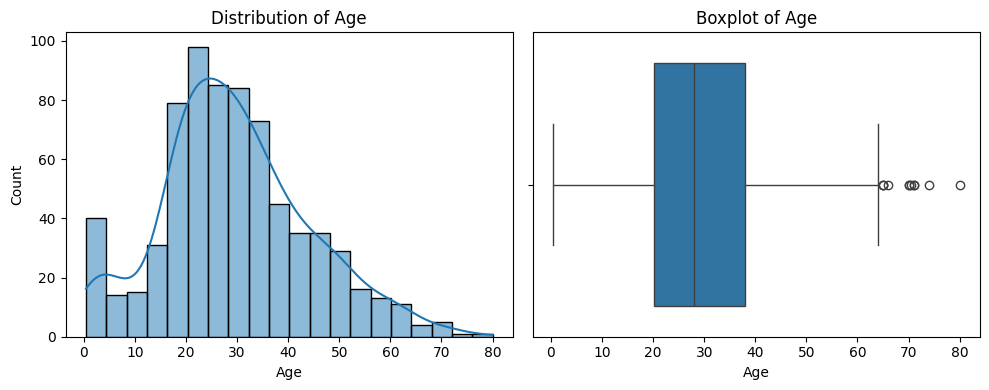

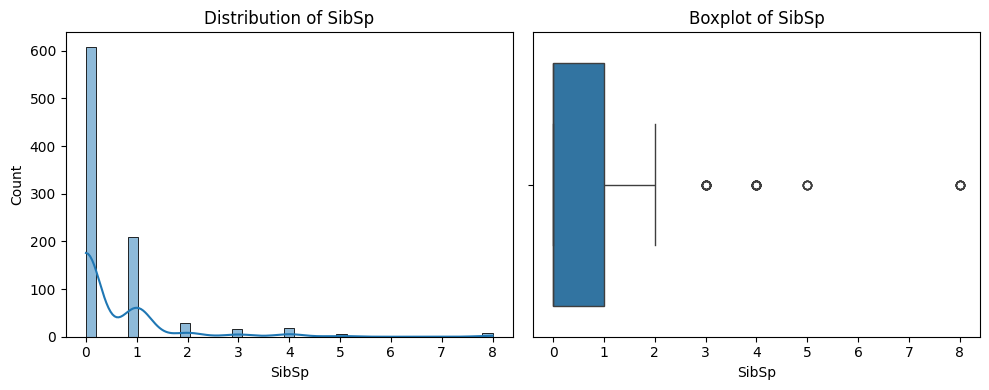

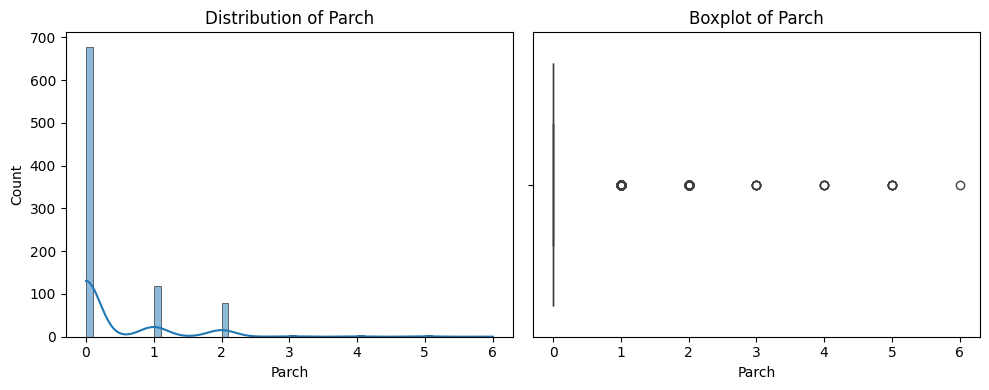

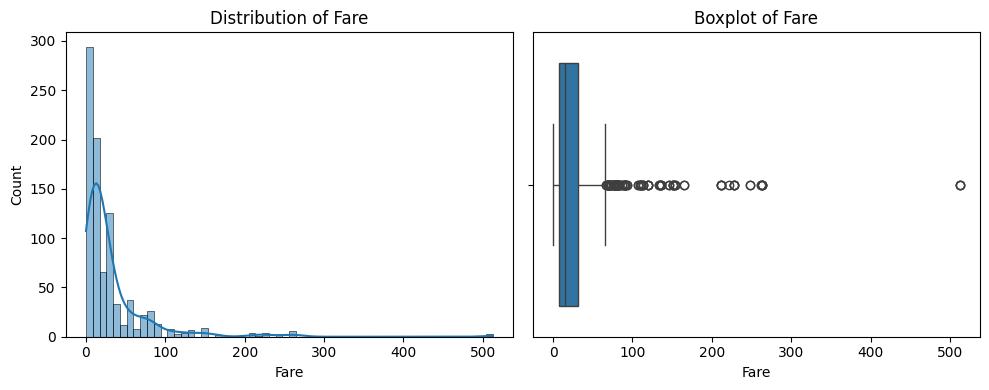

In [186]:
# 查看每个数值特征的分布情况（直方图+箱线图）
print("NUMERICAL FEATURES DISTRIBUTION:")

# 获取所有数值型特征的列名
numeric_features = numeric_df.columns

# 逐个特征画图
for feature in numeric_features:
    plt.figure(figsize=(10, 4))
    
    # 左图：直方图 + 核密度估计曲线，展示数据分布形状
    plt.subplot(1, 2, 1)
    sns.histplot(df[feature], kde=True)
    plt.title(f'Distribution of {feature}')
    
    # 右图：箱线图，展示中位数、四分位数和异常值
    plt.subplot(1, 2, 2)
    sns.boxplot(x=df[feature])
    plt.title(f'Boxplot of {feature}')
    
    plt.tight_layout()  # 自动调整子图间距
    plt.show()
print()

CATEGORICAL FEATURES DISTRIBUTION:


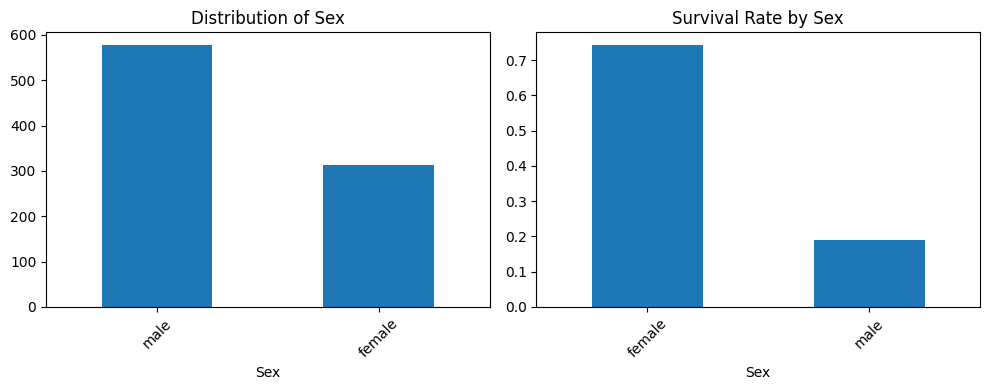

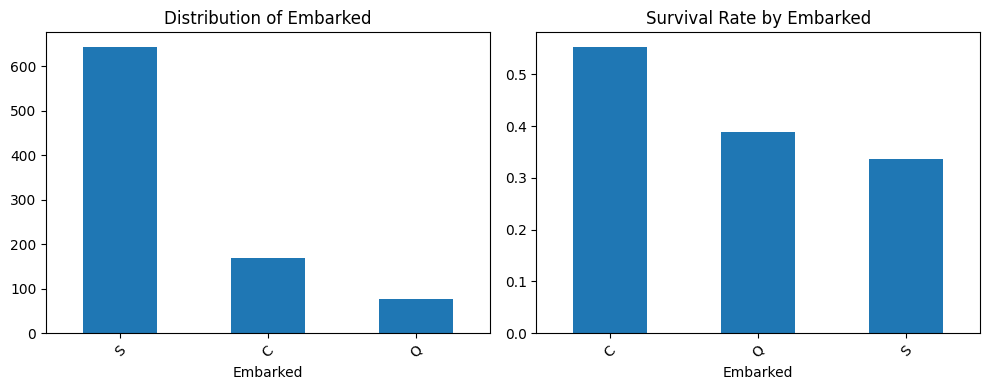

In [187]:
# 查看类别特征的分布，以及每个类别对应的生存率
print("CATEGORICAL FEATURES DISTRIBUTION:")

# 只选择类别取值种类不太多的特征（少于15种），避免图形过于拥挤
for feature in categorical_cols:
    if df[feature].nunique() < 15:
        plt.figure(figsize=(10, 4))
        
        # 左图：该类别的频数分布（条形图）
        plt.subplot(1, 2, 1)
        df[feature].value_counts().plot(kind='bar')
        plt.title(f'Distribution of {feature}')
        plt.xticks(rotation=45)
        
        # 右图：如果数据中包含幸存标签，就计算每个类别的生存率并画图
        plt.subplot(1, 2, 2)
        if 'Survived' in df.columns:
            survival_rate = df.groupby(feature)['Survived'].mean()
            survival_rate.plot(kind='bar')
            plt.title(f'Survival Rate by {feature}')
            plt.xticks(rotation=45)
        
        plt.tight_layout()
        plt.show()
print()

RELATIONSHIP BETWEEN FEATURES AND TARGET:


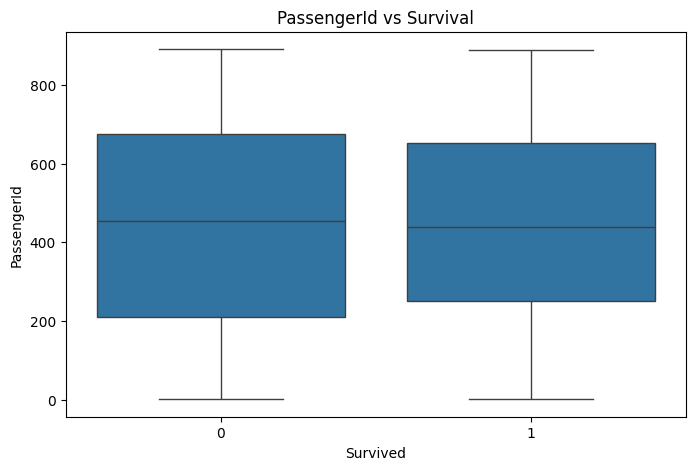

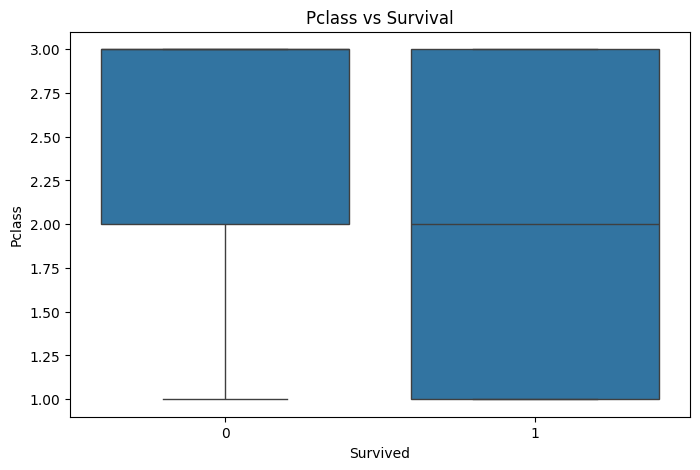

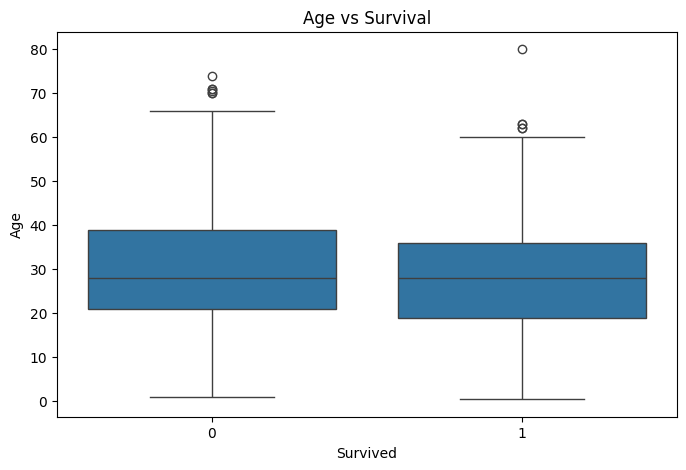

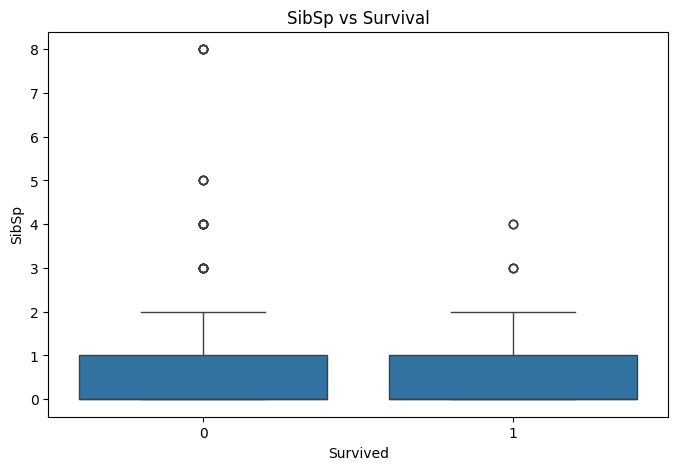

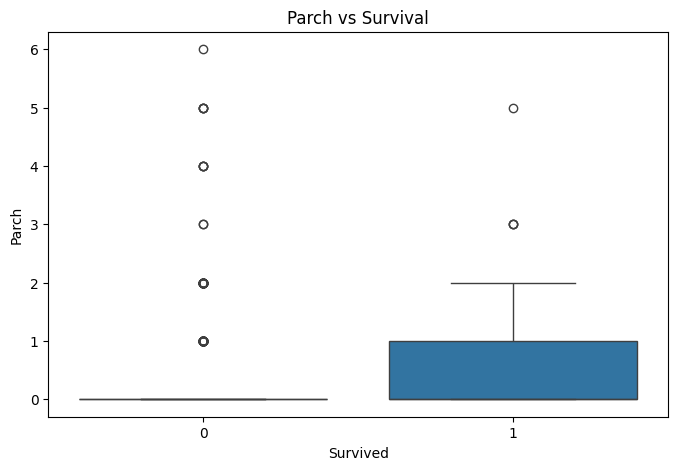

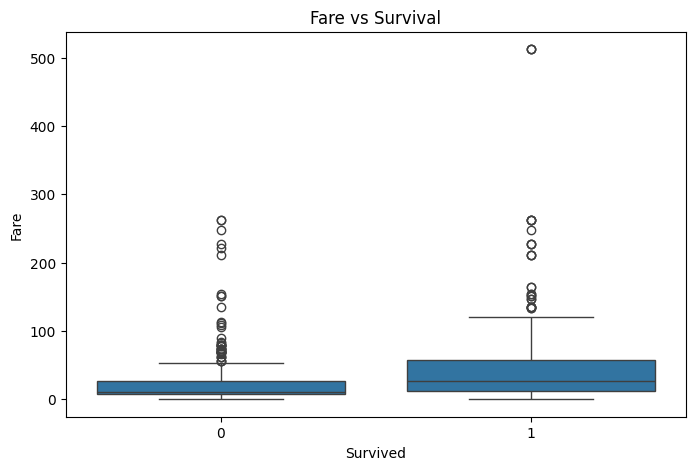

In [188]:
# 对比幸存和遇难两组在不同数值特征上的分布差异
print("RELATIONSHIP BETWEEN FEATURES AND TARGET:")

if 'Survived' in df.columns:
    for feature in numeric_features:
        if feature != 'Survived':   # 避免把目标变量自己拿来画
            plt.figure(figsize=(8, 5))
            # 用箱线图看幸存和遇难两组在该特征上的分布差异
            sns.boxplot(x='Survived', y=feature, data=df)
            plt.title(f'{feature} vs Survival')
            plt.show()
print()

OUTLIER DETECTION USING IQR:
Age: 11 outliers detected
SibSp: 46 outliers detected
Parch: 213 outliers detected
Fare: 116 outliers detected

PAIRWISE RELATIONSHIPS (Sample of 4 features):


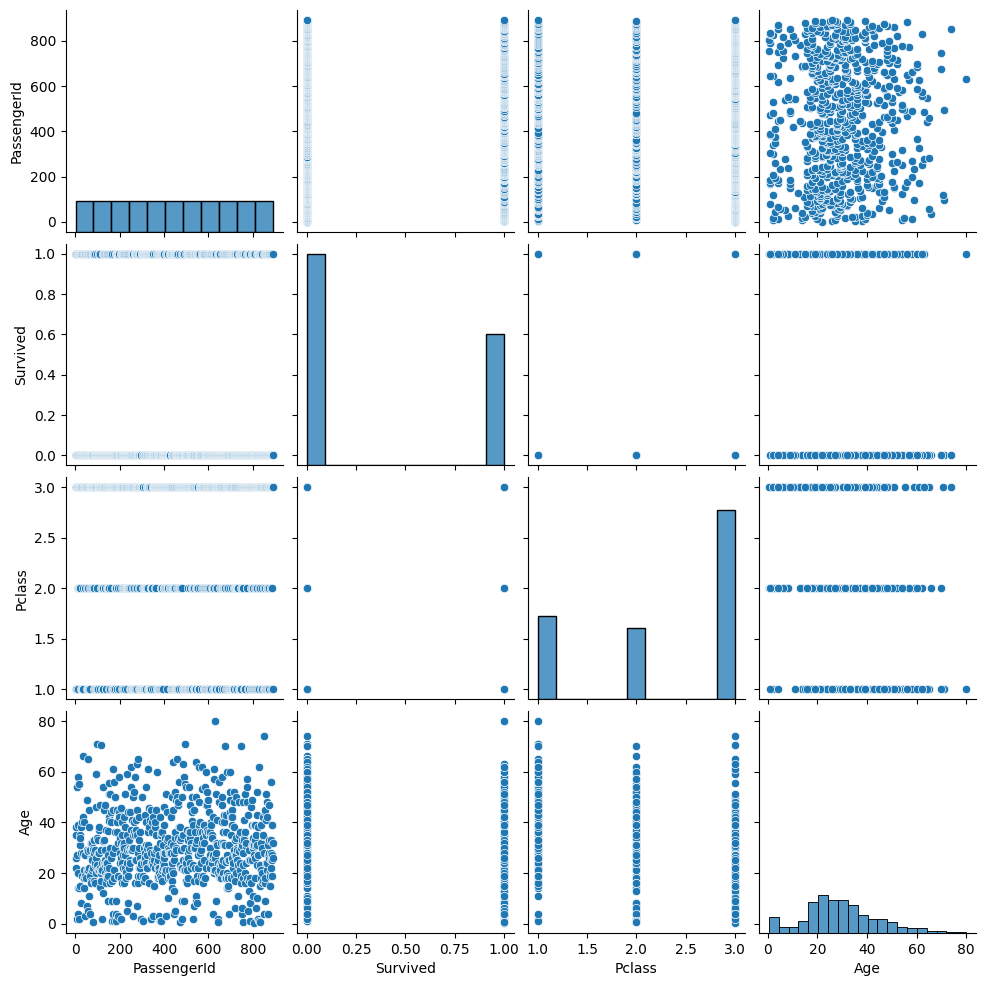

In [189]:
# 使用 IQR（四分位距）方法检测数值特征中的异常值
print("OUTLIER DETECTION USING IQR:")

for feature in numeric_features:
    # 计算第一四分位数（25%）和第三四分位数（75%）
    Q1 = df[feature].quantile(0.25)
    Q3 = df[feature].quantile(0.75)
    IQR = Q3 - Q1                     # 四分位距
    lower_bound = Q1 - 1.5 * IQR      # 下界
    upper_bound = Q3 + 1.5 * IQR      # 上界
    
    # 找出超出正常范围的行
    outliers = df[(df[feature] < lower_bound) | (df[feature] > upper_bound)]
    
    if len(outliers) > 0:
        print(f"{feature}: {len(outliers)} outliers detected")
print()

# 选取前4个数值特征，绘制两两之间的散点图矩阵
print("PAIRWISE RELATIONSHIPS (Sample of 4 features):")
if len(numeric_features) >= 4:
    sample_features = numeric_features[:4]   # 简单取前4个作为示例
    sns.pairplot(df[sample_features])        # 对角线是直方图，其他是散点图
    plt.show()
print()

MISSING VALUES VISUALIZATION:


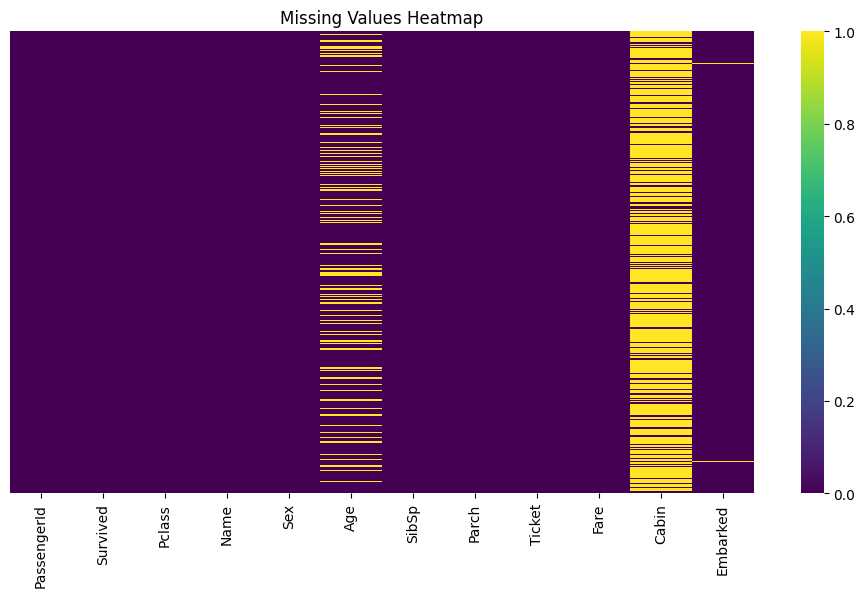


DATA QUALITY SUMMARY:
Total missing values: 866
Percentage of missing data: 8.10%
Duplicate rows: 0


In [190]:
# 可视化缺失值在数据集中的分布情况
print("MISSING VALUES VISUALIZATION:")
plt.figure(figsize=(12, 6))
# 用热力图显示哪些位置有缺失（亮色表示缺失）
sns.heatmap(df.isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title('Missing Values Heatmap')
plt.show()
print()

# 汇总数据质量的基本信息
print("DATA QUALITY SUMMARY:")
print(f"Total missing values: {df.isnull().sum().sum()}")   # 整个表中所有缺失值的总数
print(f"Percentage of missing data: {(df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100):.2f}%")  # 缺失值占总数据的比例
print(f"Duplicate rows: {df.duplicated().sum()}")          # 重复行的数量

前面都是EDA，后面开始特征工程

In [191]:
# 分类问题的评估指标：准确率、精确率、召回率、F1分数、ROC-AUC
print("DATA PREPROCESSING")

# 复制一份原始训练集，避免直接修改原数据
train = df.copy()
test = test.copy()

# 计算训练集的中位数和众数，后面用来填充缺失值
age_median = train['Age'].median()
fare_median = train['Fare'].median()
embarked_mode = train['Embarked'].mode()[0]

# 将性别（男/女）转成数值：0和1
sex_encoder = LabelEncoder()
train['Sex'] = sex_encoder.fit_transform(train['Sex'])

# 用中位数/众数填充缺失值
train['Age'].fillna(age_median, inplace=True)
train['Embarked'].fillna(embarked_mode, inplace=True)
train['Fare'].fillna(fare_median, inplace=True)
# Cabin 列：有 cabin 记为 1，缺失记为 0
train['Cabin'] = train['Cabin'].notna().astype(int)

# 从名字中提取称呼（Mr, Mrs, Miss 等）
train['Title'] = train['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
# 把罕见的称呼归为一类
rare_titles = ['Lady', 'Countess','Capt', 'Col','Don', 'Dr', 'Major', 'Rev', 'Sir', 'Jonkheer', 'Dona']
train['Title'] = train['Title'].replace(rare_titles, 'Rare')
train['Title'] = train['Title'].replace(['Mlle', 'Ms'], 'Miss')
train['Title'] = train['Title'].replace('Mme', 'Mrs')
# 将称呼映射为数字，方便模型使用
title_mapping = {"Mr": 1, "Miss": 2, "Mrs": 3, "Master": 4, "Rare": 5}
train['Title'] = train['Title'].map(title_mapping)
train['Title'].fillna(0, inplace=True)

# 家庭总人数 = 兄弟姐妹/配偶 + 父母/子女 + 本人
train['FamilySize'] = train['SibSp'] + train['Parch'] + 1
# 是否独自一人
train['IsAlone'] = (train['FamilySize'] == 1).astype(int)

# 将 Embarked 和 Pclass 转为哑变量（one-hot）
train = pd.get_dummies(train, columns=['Embarked'], prefix='Emb')
train = pd.get_dummies(train, columns=['Pclass'], prefix='Pclass')

# ------------------------------
# 对测试集做同样的处理，但填充值必须用训练集的统计量
# ------------------------------
test['Age'].fillna(age_median, inplace=True)
test['Embarked'].fillna(embarked_mode, inplace=True)
test['Fare'].fillna(fare_median, inplace=True)
test['Cabin'] = test['Cabin'].notna().astype(int)

# 直接用训练集上训练好的 LabelEncoder 转换性别
test['Sex'] = sex_encoder.transform(test['Sex'])

# Title 特征（映射规则和训练集保持一致）
test['Title'] = test['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
test['Title'] = test['Title'].replace(rare_titles, 'Rare')
test['Title'] = test['Title'].replace(['Mlle', 'Ms'], 'Miss')
test['Title'] = test['Title'].replace('Mme', 'Mrs')
test['Title'] = test['Title'].map(title_mapping)
test['Title'].fillna(0, inplace=True)

test['FamilySize'] = test['SibSp'] + test['Parch'] + 1
test['IsAlone'] = (test['FamilySize'] == 1).astype(int)

# 测试集也做 one-hot 编码
test = pd.get_dummies(test, columns=['Embarked'], prefix='Emb')
test = pd.get_dummies(test, columns=['Pclass'], prefix='Pclass')

# 定义我们要使用的特征列
features = ['Sex', 'Age', 'Fare', 'Cabin', 'Title', 'FamilySize', 'IsAlone', 
            'Emb_C', 'Emb_Q', 'Emb_S', 'Pclass_1', 'Pclass_2', 'Pclass_3']

# 提取特征和标签
X = train[features]
y = train['Survived']
X_test = test[features]

print(f"Features: {len(features)}")
print(f"Target distribution: {y.value_counts(normalize=True).to_dict()}")

# 划分训练集和验证集（分层抽样，保持标签比例）
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# ================= 使用 SimpleImputer 强力处理缺失值 =================
from sklearn.impute import SimpleImputer

# 用训练集的中位数填充所有缺失值（适用于数值型特征）
imputer = SimpleImputer(strategy='median')
X_train_imputed = imputer.fit_transform(X_train)
X_val_imputed = imputer.transform(X_val)
X_imputed = imputer.transform(X)
X_test_imputed = imputer.transform(X_test)

# 标准化特征（逻辑回归这类模型对尺度敏感）
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.transform(X_val_imputed)
X_scaled = scaler.transform(X_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

# 训练第一个模型：逻辑回归（作为基线）
print("\nMODEL 1: BASELINE - LOGISTIC REGRESSION")
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_val_scaled)
y_prob_lr = lr.predict_proba(X_val_scaled)[:, 1]

# 输出验证集上的各项指标
print(f"Accuracy: {accuracy_score(y_val, y_pred_lr):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_lr):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_lr):.4f}")
print(f"F1 Score: {f1_score(y_val, y_pred_lr):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_prob_lr):.4f}")

DATA PREPROCESSING
Features: 13
Target distribution: {0: 0.6161616161616161, 1: 0.3838383838383838}

MODEL 1: BASELINE - LOGISTIC REGRESSION
Accuracy: 0.8045
Precision: 0.7656
Recall: 0.7101
F1 Score: 0.7368
ROC-AUC: 0.8513


<>:25: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:57: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:25: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
<>:57: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
C:\Users\xiaoh\AppData\Local\Temp\ipykernel_44176\2604074947.py:25: SyntaxWarning: "\." is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\."? A raw string is also an option.
  train['Title'] = train['Name'].str.extract(' ([A-Za-z]+)\.', expand=False)
C:\Users\xiaoh\AppData\Local\Temp\ipykernel_44176\2604074947.py:57: SyntaxWarning: "\." is a

In [192]:
# 第二个模型：随机森林（作为树模型的基线，不需要标准化）
print("\nMODEL 2: RANDOM FOREST (BASELINE)")

# 初始化随机森林分类器，100棵树，固定随机种子保证可复现
rf = RandomForestClassifier(random_state=42, n_estimators=100)

# 注意：随机森林不依赖特征缩放，所以直接用原始特征 X_train 而非缩放后的版本
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_val)
y_prob_rf = rf.predict_proba(X_val)[:, 1]  # 取正类的概率，用于计算 AUC

# 输出各项评估指标
print(f"Accuracy: {accuracy_score(y_val, y_pred_rf):.4f}")
print(f"Precision: {precision_score(y_val, y_pred_rf):.4f}")
print(f"Recall: {recall_score(y_val, y_pred_rf):.4f}")
print(f"F1 Score: {f1_score(y_val, y_pred_rf):.4f}")
print(f"ROC-AUC: {roc_auc_score(y_val, y_prob_rf):.4f}")


MODEL 2: RANDOM FOREST (BASELINE)
Accuracy: 0.7989
Precision: 0.7391
Recall: 0.7391
F1 Score: 0.7391
ROC-AUC: 0.8329


In [193]:
# ==================== 完整的交叉验证对比（含缺失值处理和标准化） ====================
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

print("\nCROSS-VALIDATION COMPARISON")

# 定义模型
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42, n_estimators=100)
}

cv_results = {}

for name, model in models.items():
    if name == 'Logistic Regression':
        # 逻辑回归：填充缺失值 → 标准化 → 模型
        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),  # 用中位数填充
            ('scaler', StandardScaler()),                   # 标准化
            ('clf', model)
        ])
    else:
        # 树模型：填充缺失值 → 模型（不需要标准化）
        pipe = Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('clf', model)
        ])
    
    # 5折交叉验证，评估指标为准确率
    scores = cross_val_score(pipe, X_train, y_train, cv=5, scoring='accuracy')
    cv_results[name] = scores.mean()
    # 输出平均准确率 ± 2倍标准差（约95%置信区间）
    print(f"{name}: Mean CV Accuracy = {scores.mean():.4f} (+/- {scores.std()*2:.4f})")


CROSS-VALIDATION COMPARISON
Logistic Regression: Mean CV Accuracy = 0.8175 (+/- 0.0414)
Random Forest: Mean CV Accuracy = 0.7951 (+/- 0.1031)
Gradient Boosting: Mean CV Accuracy = 0.8246 (+/- 0.0698)


In [194]:
# 对随机森林进行超参数调优（随机森林对缺失数据容忍度高，精度也不错）
print("\nHYPERPARAMETER TUNING FOR RANDOM FOREST")

# 定义要搜索的参数组合
param_grid = {
    'n_estimators': [25, 75, 100],        # 树的数量
    'max_depth': [2, 5, 10],              # 每棵树的最大深度
    'min_samples_split': [10, 13, 15],    # 内部节点再划分所需的最小样本数
    'min_samples_leaf': [1, 2, 4]         # 叶节点最少样本数
}

rf_for_grid = RandomForestClassifier(random_state=42)
# 网格搜索，5折交叉验证，n_jobs=-1表示用所有CPU核心，verbose=0不输出过程
grid_search = GridSearchCV(rf_for_grid, param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=0)
grid_search.fit(X_train, y_train)

print(f"Best Parameters: {grid_search.best_params_}")
print(f"Best CV Score: {grid_search.best_score_:.4f}")

# 用最佳模型在验证集上评估
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_val)
print(f"Test Accuracy (Tuned): {accuracy_score(y_val, y_pred_best):.4f}")


HYPERPARAMETER TUNING FOR RANDOM FOREST
Best Parameters: {'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 13, 'n_estimators': 25}
Best CV Score: 0.8301
Test Accuracy (Tuned): 0.8045


In [195]:
#集成模型：投票分类器
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler


# 1. 对训练集和验证集进行缺失值填充（使用训练集的中位数）
imputer = SimpleImputer(strategy='median')
X_train_imp = imputer.fit_transform(X_train)   # 拟合训练集，并转换
X_val_imp = imputer.transform(X_val)            # 用训练集的中位数填充验证集

# 2. 标准化（逻辑回归需要，树模型无影响）
scaler = StandardScaler()
X_train_imp_scaled = scaler.fit_transform(X_train_imp)
X_val_imp_scaled = scaler.transform(X_val_imp)

# 3. 定义投票分类器（使用处理后的数据）
voting_clf = VotingClassifier(
    estimators=[
        ('lr', LogisticRegression(random_state=42, max_iter=1000)),
        ('rf', RandomForestClassifier(random_state=42, n_estimators=200, max_depth=10)),
        ('gb', GradientBoostingClassifier(random_state=42, n_estimators=100))
    ],
    voting='soft'  # soft 模式：取概率平均值
)

# 4. 训练和预测（使用处理后的数据）
voting_clf.fit(X_train_imp_scaled, y_train)
y_pred_voting = voting_clf.predict(X_val_imp_scaled)
print(f"Voting Ensemble Accuracy: {accuracy_score(y_val, y_pred_voting):.4f}")


print("\n重新生成各模型在验证集上的预测（基于填充+标准化数据）...")

# 逻辑回归（基线）
lr = LogisticRegression(random_state=42, max_iter=1000)
lr.fit(X_train_imp_scaled, y_train)
y_pred_lr = lr.predict(X_val_imp_scaled)

# 随机森林（基线）
rf_base = RandomForestClassifier(random_state=42, n_estimators=100)
rf_base.fit(X_train_imp, y_train)   # 树模型不需要标准化
y_pred_rf = rf_base.predict(X_val_imp)

# 随机森林（调优后）—— 假设你之前已经通过 grid_search 得到了 best_rf
# 如果 best_rf 已存在，直接使用填充后的数据重新拟合
best_rf.fit(X_train_imp, y_train)
y_pred_best = best_rf.predict(X_val_imp)

# 计算各项指标
print("\nMODEL COMPARISON SUMMARY")
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'Random Forest (Tuned)', 'Voting Ensemble'],
    'Accuracy': [
        accuracy_score(y_val, y_pred_lr),
        accuracy_score(y_val, y_pred_rf),
        accuracy_score(y_val, y_pred_best),
        accuracy_score(y_val, y_pred_voting)
    ],
    'Precision': [
        precision_score(y_val, y_pred_lr),
        precision_score(y_val, y_pred_rf),
        precision_score(y_val, y_pred_best),
        precision_score(y_val, y_pred_voting)
    ],
    'Recall': [
        recall_score(y_val, y_pred_lr),
        recall_score(y_val, y_pred_rf),
        recall_score(y_val, y_pred_best),
        recall_score(y_val, y_pred_voting)
    ]
})

print(results.sort_values('Accuracy', ascending=False))

Voting Ensemble Accuracy: 0.8268

重新生成各模型在验证集上的预测（基于填充+标准化数据）...

MODEL COMPARISON SUMMARY
                   Model  Accuracy  Precision    Recall
3        Voting Ensemble  0.826816   0.806452  0.724638
2  Random Forest (Tuned)  0.810056   0.818182  0.652174
1          Random Forest  0.804469   0.757576  0.724638
0    Logistic Regression  0.804469   0.765625  0.710145



CONFUSION MATRIX (BEST MODEL)


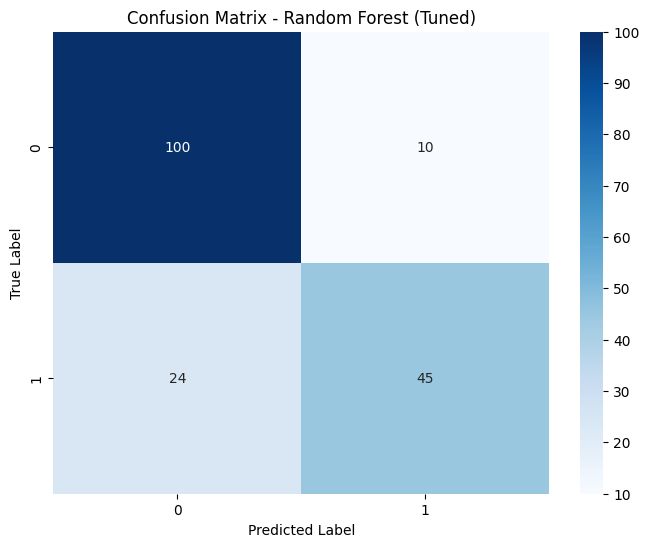

In [196]:
# 混淆矩阵（最佳模型）
print("\nCONFUSION MATRIX (BEST MODEL)")

# 计算最佳随机森林模型在验证集上的混淆矩阵
cm = confusion_matrix(y_val, y_pred_best)
plt.figure(figsize=(8, 6))
# 用热力图展示：annot=True 显示数字，fmt='d' 表示整数格式
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Random Forest (Tuned)')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [197]:
# 假设一个业务代价矩阵：不同错误预测带来的成本不同
cost_matrix = {
    'TP': 0,      # 正确预测幸存：没有成本
    'TN': 0,      # 正确预测遇难：也没有成本
    'FP': 1,      # 误报（预测幸存实际遇难）：虚惊一场，成本较低
    'FN': 5       # 漏报（预测遇难实际幸存）：错过救援，成本很高
}

# 根据混淆矩阵计算总业务代价
cm = confusion_matrix(y_val, y_pred_best)
total_cost = (cm[0,1] * cost_matrix['FP'] +   # cm[0,1] 是 FP 的数量
              cm[1,0] * cost_matrix['FN'])    # cm[1,0] 是 FN 的数量
print(f"模型的总业务代价: {total_cost}")

模型的总业务代价: 130


In [198]:
# 对比调参前后的混淆矩阵，看看优化带来了什么变化
cm_baseline = confusion_matrix(y_val, y_pred_rf)   # 调参前的随机森林
cm_tuned = confusion_matrix(y_val, y_pred_best)    # 调参后的最佳模型

print("baseline混淆矩阵:")
print(cm_baseline)
print("\n调优后模型混淆矩阵:")  
print(cm_tuned)

# 计算错误数量的减少（改进）
fp_improvement = cm_baseline[0,1] - cm_tuned[0,1]   # 假阳性减少的数量
fn_improvement = cm_baseline[1,0] - cm_tuned[1,0]   # 假阴性减少的数量
print(f"\n改进情况: 减少了 {fp_improvement} 个误报，{fn_improvement} 个漏报")

baseline混淆矩阵:
[[94 16]
 [19 50]]

调优后模型混淆矩阵:
[[100  10]
 [ 24  45]]

改进情况: 减少了 6 个误报，-5 个漏报



FEATURE IMPORTANCE ANALYSIS


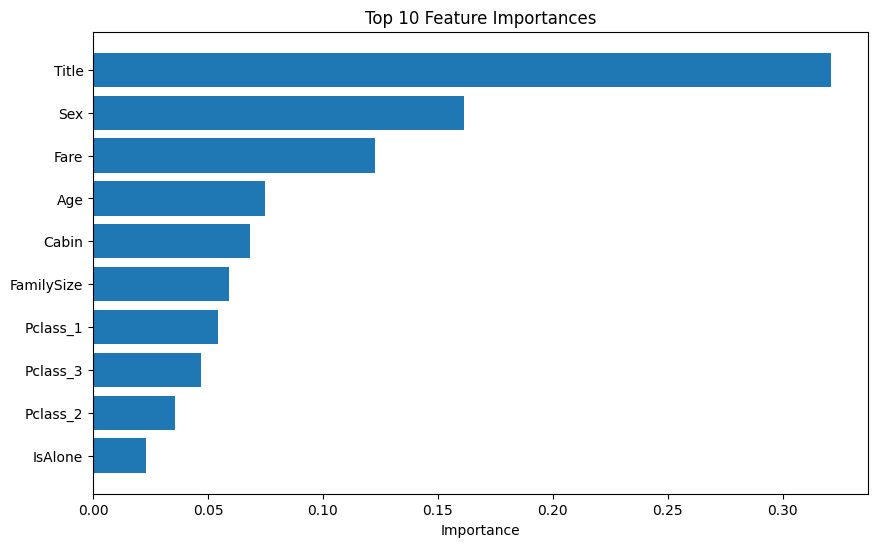

TOP 10 FEATURES:
       feature  importance
4        Title    0.321132
0          Sex    0.161504
2         Fare    0.122526
1          Age    0.074768
3        Cabin    0.068057
5   FamilySize    0.058980
10    Pclass_1    0.054394
12    Pclass_3    0.046755
11    Pclass_2    0.035527
6      IsAlone    0.023024


In [199]:
# 查看调优后随机森林的特征重要性，了解哪些特征对预测最有贡献
print("\nFEATURE IMPORTANCE ANALYSIS")

feature_importance = pd.DataFrame({
    'feature': features,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

# 画水平条形图，只显示前10个最重要的特征
plt.figure(figsize=(10, 6))
plt.barh(feature_importance['feature'][:10], feature_importance['importance'][:10])
plt.xlabel('Importance')
plt.title('Top 10 Feature Importances')  # 重要性 >0.1 算高，0.05-0.1 中等，<0.05 可能像噪音
plt.gca().invert_yaxis()  # 让最重要的排在顶部
plt.show()

print("TOP 10 FEATURES:")
print(feature_importance.head(10))

# 后面可以思考：这些重要性是否符合实际业务逻辑？
# 如果想简化模型，可以尝试去掉重要性很低的特征（噪音），但要注意可能会破坏某些特征之间的交互关系。
# 另外需要警惕数据泄露：比如某些特征在真实预测场景中无法提前获取，那就不应该放入模型。

In [200]:
# 最终模型：

# 1. 对全部训练集 X 和测试集 X_test 进行缺失值填充（使用训练集的中位数）
from sklearn.impute import SimpleImputer
imputer_final = SimpleImputer(strategy='median')
X_imputed = imputer_final.fit_transform(X)        # 拟合训练集，并转换全部X
X_test_imputed = imputer_final.transform(X_test)  # 用相同中位数填充测试集

# 2. 标准化（逻辑回归需要，树模型无影响）
scaler_final = StandardScaler()
X_scaled = scaler_final.fit_transform(X_imputed)      # 标准化全部训练数据
X_test_scaled = scaler_final.transform(X_test_imputed) # 标准化测试数据

# 3. 选择最终模型（这里用投票集成模型，也可以换成 best_rf）
final_model = voting_clf   # 假设 voting_clf 已经定义（但还没拟合）
# 注意：voting_clf 内部包含逻辑回归，需要标准化后的数据；随机森林和梯度提升也可以接受标准化数据
final_model.fit(X_scaled, y)   # 训练最终模型

# 4. 预测测试集（训练集预测可选，用于自查）
final_pred = final_model.predict(X_test_scaled)   # 测试集预测

# 5. 生成提交文件
submission = pd.DataFrame()
submission['PassengerId'] = test['PassengerId']
submission['Survived'] = final_pred
submission.to_csv('submission.csv', index=False)
print("Submission file created: submission.csv")

Submission file created: submission.csv
